# BSGP 7030 — Assignment 5a: Machine Learning in Python (AI-Generated Rebuild)

**Author:** Dalton Dencklau
**Email:** dencklau.1@osu.edu
**Course:** BSGP 7030
**Assignment:** 5a — Python ML Workflow (Part B: AI-assisted rebuild)
**Dataset:** Iris flower dataset (150 observations, 4 numeric features, 3 classes)

This notebook was generated end-to-end by Claude (Anthropic) from a single high-level prompt,
as the "rebuild from a high-level prompt" comparison step of Assignment 5. It follows the same
overall project shape as the manual Part A submission (load data, summarize, visualize,
spot-check several classification algorithms via 10-fold cross-validation, select a final
model, and evaluate it on a held-out validation set) but the code was written independently
rather than copied from any single source.


## 1. Environment Check

Confirm the key libraries are installed and log their versions for reproducibility.

In [1]:
import sys
import sklearn
import pandas
import matplotlib
import numpy
import scipy

print('Python:', sys.version)
print('scikit-learn:', sklearn.__version__)
print('pandas:', pandas.__version__)
print('matplotlib:', matplotlib.__version__)
print('numpy:', numpy.__version__)
print('scipy:', scipy.__version__)


Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
scikit-learn: 1.8.0
pandas: 3.0.2
matplotlib: 3.10.8
numpy: 2.4.4
scipy: 1.17.1


## 2. Load the Dataset

Load the iris dataset from a local CSV file (no header row; column names assigned manually).

In [2]:
import pandas as pd

column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_df = pd.read_csv('iris.csv', header=None, names=column_names)
iris_df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Summarize the Dataset

Basic shape, a peek at the rows, descriptive statistics, and class balance.

In [3]:
print('Shape:', iris_df.shape)
iris_df.head(10)


Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris_df.groupby('species').size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

## 4. Visualize the Dataset

Univariate box plots and histograms, then a multivariate scatter matrix to look for structure between features.

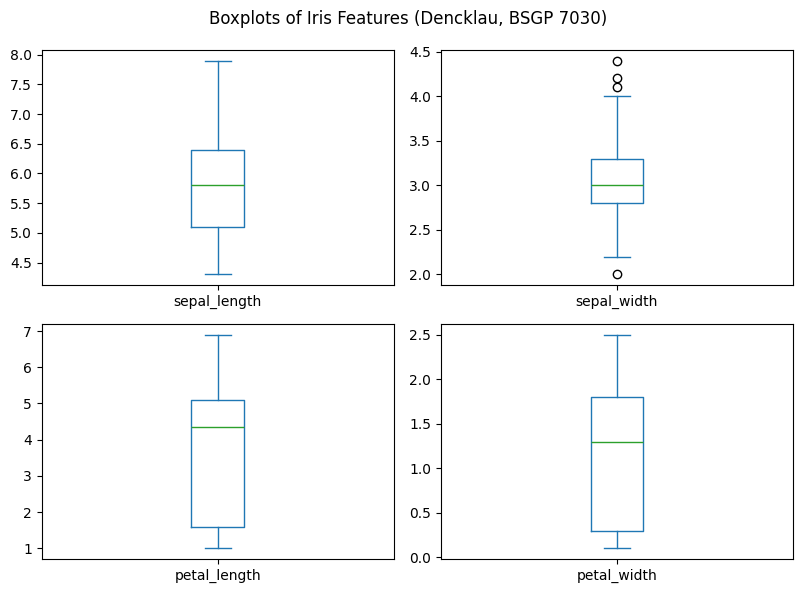

In [6]:
%matplotlib inline
from matplotlib import pyplot as plt

iris_df.plot(kind='box', subplots=True, layout=(2, 2), sharex=False, sharey=False, figsize=(8, 6))
plt.suptitle('Boxplots of Iris Features (Dencklau, BSGP 7030)')
plt.tight_layout()
plt.show()


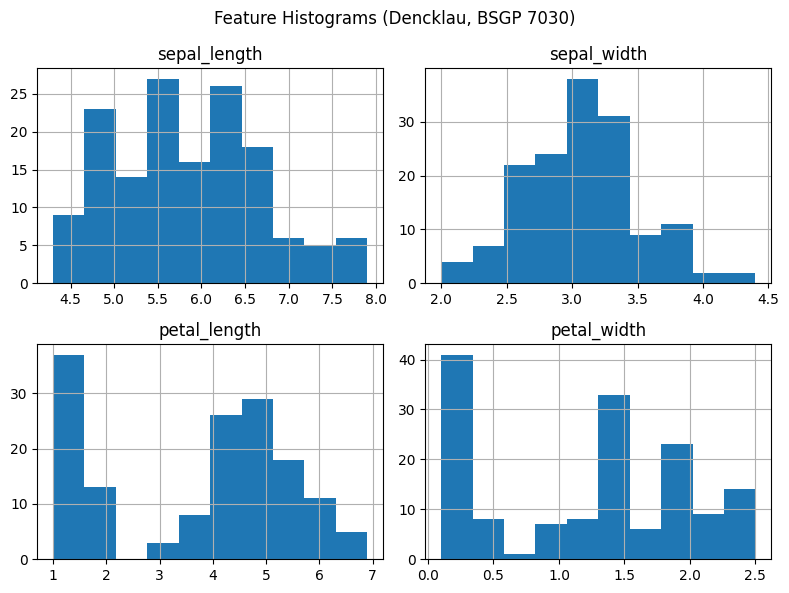

In [7]:
iris_df.hist(figsize=(8, 6))
plt.suptitle('Feature Histograms (Dencklau, BSGP 7030)')
plt.tight_layout()
plt.show()


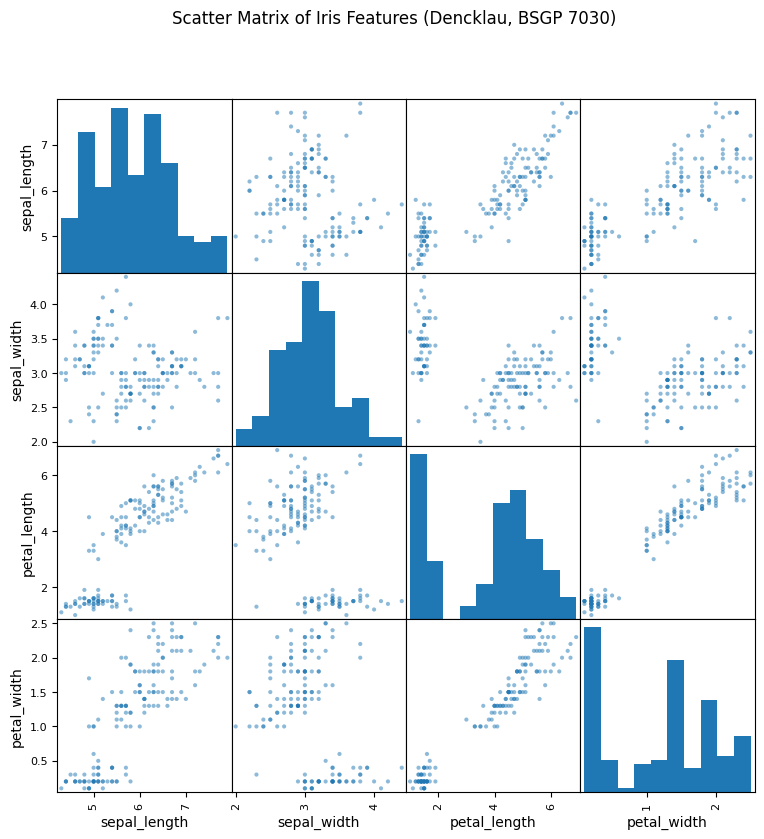

In [8]:
from pandas.plotting import scatter_matrix

scatter_matrix(iris_df, figsize=(9, 9))
plt.suptitle('Scatter Matrix of Iris Features (Dencklau, BSGP 7030)')
plt.show()


## 5. Split the Data and Spot-Check Algorithms

Hold back 20% of the data as an untouched validation set. Use stratified 10-fold cross-validation
on the remaining 80% to estimate accuracy for six candidate classifiers.

In [9]:
from sklearn.model_selection import train_test_split

array = iris_df.values
X = array[:, 0:4]
y = array[:, 4]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)
print('Training rows:', X_train.shape[0], '| Validation rows:', X_val.shape[0])


Training rows: 120 | Validation rows: 30


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

candidate_models = [
    ('LR',   LogisticRegression(solver='lbfgs', max_iter=1000)),
    ('LDA',  LinearDiscriminantAnalysis()),
    ('KNN',  KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier(random_state=1)),
    ('NB',   GaussianNB()),
    ('SVM',  SVC(gamma='auto')),
]

cv_scores = []
cv_names = []
for name, model in candidate_models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores)
    cv_names.append(name)
    print(f'{name}: {scores.mean():.4f} ({scores.std():.4f})')


LR: 0.9417 (0.0534)
LDA: 0.9750 (0.0382)
KNN: 0.9500 (0.0553)
CART: 0.9167 (0.0745)
NB: 0.9500 (0.0764)
SVM: 0.9667 (0.0408)


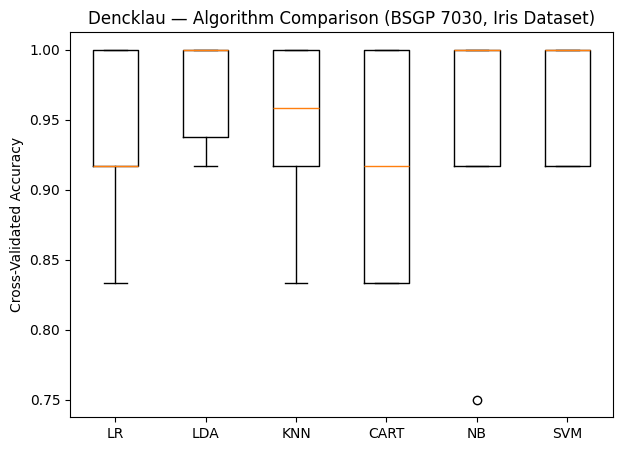

In [11]:
plt.figure(figsize=(7, 5))
plt.boxplot(cv_scores, tick_labels=cv_names)
plt.title('Dencklau — Algorithm Comparison (BSGP 7030, Iris Dataset)')
plt.ylabel('Cross-Validated Accuracy')
plt.show()


## 6. Fit the Final Model and Evaluate on the Validation Set

Support Vector Machines and Linear Discriminant Analysis are both strong, simple candidates on
this dataset; SVM is used here as the final model, fit on the full training split and evaluated
once on the held-out validation set.

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

final_model = SVC(gamma='auto')
final_model.fit(X_train, y_train)
predictions = final_model.predict(X_val)

print('Validation accuracy:', accuracy_score(y_val, predictions))
print()
print('Confusion matrix:')
print(confusion_matrix(y_val, predictions))
print()
print('Classification report:')
print(classification_report(y_val, predictions))


Validation accuracy: 0.9666666666666667

Confusion matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Summary

This notebook walked through a complete, reproducible supervised-learning workflow on the iris
dataset: environment verification, data loading, exploratory summaries and visualizations,
stratified 10-fold cross-validation across six classifiers, and a final hold-out evaluation.
The environment used to run this notebook is captured in `environment.yml` in this repository.
